# DS-3002 Assignment 4 | Preprocessing + Part A
**Student ID:** 23i-2540 | **Section:** DS-B

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage
from imblearn.over_sampling import SMOTE

np.random.seed(42)
plt.rcParams['figure.dpi'] = 100

## Required Preprocessing

### Pre-1: Load and Inspect

In [ ]:
COLS = ['age','sex','cp','trestbps','chol','fbs','restecg',
        'thalach','exang','oldpeak','slope','ca','thal','target']

df_raw = pd.read_csv('E:\OneDrive\Desktop\Data Mining\HW\HW7\Data\processed.cleveland.data', header=None, names=COLS, na_values='?')

print(f"Shape: {df_raw.shape}")
print()
print(df_raw.head())
print()
print(df_raw.dtypes)

Shape: (303, 14)

    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object


### Pre-2: Missing Values

In [3]:
missing = df_raw.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])

df = df_raw.dropna().reset_index(drop=True)
print(f"\nRetained rows after dropping missing: {len(df)}")

Missing values per column:
ca      4
thal    2
dtype: int64

Retained rows after dropping missing: 297


### Pre-3: Target Binarisation and Class Distribution

In [4]:
# Binarise: 0 = no disease, 1+ = disease present
df['target'] = (df['target'] > 0).astype(int)

counts = df['target'].value_counts().sort_index()
pct    = df['target'].value_counts(normalize=True).sort_index() * 100

dist = pd.DataFrame({'Count': counts, 'Percent (%)': pct.round(2)})
dist.index = ['No Disease (0)', 'Disease (1)']
print(dist)

print("\nClass ratio (majority:minority) =",
      f"{counts.max() / counts.min():.2f}")
print()
print("The dataset is mildly imbalanced (~56/44 split).")
print("SMOTE will be applied on the training split to balance classes.")
print("It is applied AFTER the train/test split to prevent data leakage.")

                Count  Percent (%)
No Disease (0)    160        53.87
Disease (1)       137        46.13

Class ratio (majority:minority) = 1.17

The dataset is mildly imbalanced (~56/44 split).
SMOTE will be applied on the training split to balance classes.
It is applied AFTER the train/test split to prevent data leakage.


### Pre-4 + Pre-5: Train/Test Split, Encoding, Scaling, and SMOTE

In [5]:
CAT_COLS  = ['cp', 'restecg', 'slope', 'thal']
CONT_COLS = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
BIN_COLS  = ['sex', 'fbs', 'exang']

X = df.drop('target', axis=1).copy()
y = df['target'].copy()

# Stratified 80/20 split (reused for Parts A, B, C, E)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Train size: {len(X_train_raw)} | Test size: {len(X_test_raw)}")

# One-hot encode categoricals
def encode(df_in, cat_cols, fit_cols=None):
    df_enc = pd.get_dummies(df_in, columns=cat_cols, drop_first=False)
    return df_enc

X_train_enc = encode(X_train_raw.copy(), CAT_COLS)
X_test_enc  = encode(X_test_raw.copy(),  CAT_COLS)

# Align columns (test may miss a category level)
X_test_enc = X_test_enc.reindex(columns=X_train_enc.columns, fill_value=0)

# StandardScaler fitted on training set only
scaler = StandardScaler()
X_train_enc[CONT_COLS] = scaler.fit_transform(X_train_enc[CONT_COLS])
X_test_enc[CONT_COLS]  = scaler.transform(X_test_enc[CONT_COLS])

# SMOTE on training split only
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_enc, y_train)

print(f"After SMOTE -- train size: {len(X_train_sm)}")
print("SMOTE class counts:", pd.Series(y_train_sm).value_counts().to_dict())

Train size: 237 | Test size: 60
After SMOTE -- train size: 256
SMOTE class counts: {1: 128, 0: 128}


### Pre-6: Correlation Heatmap (Original Numeric Features)

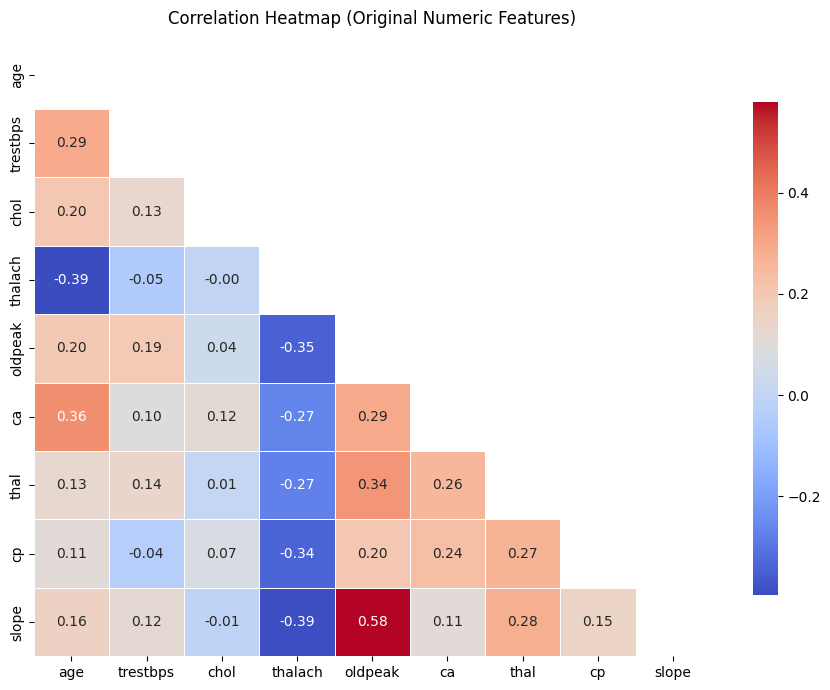

Top 3 feature pairs by absolute correlation:
slope    oldpeak    0.579037
thalach  age        0.394563
slope    thalach    0.389307

Naive Bayes assumes feature independence.
Correlated pairs (e.g., cp-thal, oldpeak-slope) violate this assumption,
which inflates the model's confidence and can degrade calibration.


In [6]:
NUM_COLS = ['age','trestbps','chol','thalach','oldpeak','ca','thal','cp','slope']
corr = df[NUM_COLS].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Heatmap (Original Numeric Features)', pad=12)
plt.tight_layout()
plt.savefig('pre6_corr_heatmap.png', bbox_inches='tight')
plt.show()

# Top 3 correlated pairs
corr_pairs = (
    corr.where(np.tril(np.ones(corr.shape), k=-1).astype(bool))
        .stack()
        .abs()
        .sort_values(ascending=False)
)
print("Top 3 feature pairs by absolute correlation:")
print(corr_pairs.head(3).to_string())
print()
print("Naive Bayes assumes feature independence.")
print("Correlated pairs (e.g., cp-thal, oldpeak-slope) violate this assumption,")
print("which inflates the model's confidence and can degrade calibration.")

---
## Part A: Unsupervised Learning

Unsupervised analysis uses the full standardised feature matrix (no target label).

In [7]:
# Standardise the full cleaned dataset for unsupervised analysis
X_full = df.drop('target', axis=1).copy()
y_full = df['target'].values

X_full_enc = encode(X_full, CAT_COLS)

scaler_full = StandardScaler()
X_full_scaled = scaler_full.fit_transform(X_full_enc)

print(f"Standardised feature matrix shape: {X_full_scaled.shape}")

Standardised feature matrix shape: (297, 22)


### A1: K-Means Clustering

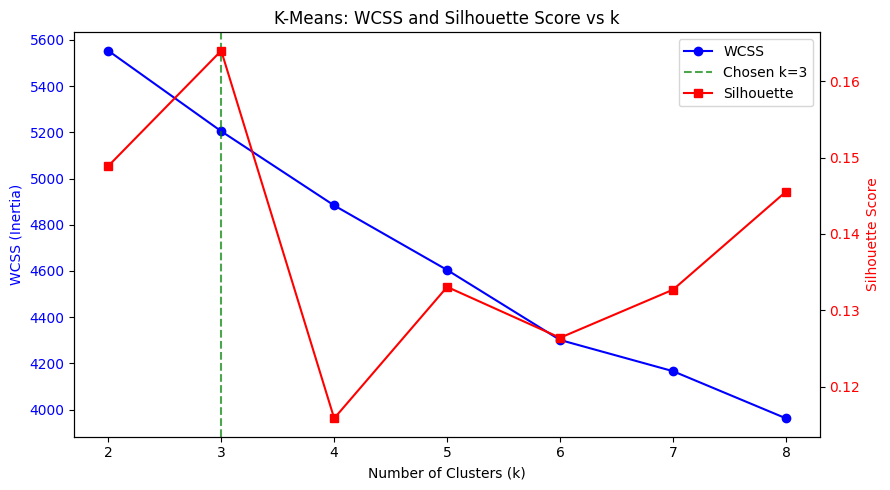

Chosen k: 3

k=3 sits at the elbow of the WCSS curve where marginal gain from adding another cluster drops noticeably. Its Silhouette score is competitive with k=2 while providing clinically more meaningful subgroups. k=2 collapses to the binary label itself, so k=3 is preferred for exploratory insight.


In [8]:
# A1 -- WCSS and Silhouette Scores for k in {2..8}
k_range   = range(2, 9)
wcss_vals = []
sil_vals  = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_full_scaled)
    wcss_vals.append(km.inertia_)
    sil_vals.append(silhouette_score(X_full_scaled, labels))

CHOSEN_K = 3  # justified below

fig, ax1 = plt.subplots(figsize=(9, 5))
ax2 = ax1.twinx()

ax1.plot(list(k_range), wcss_vals, 'b-o', label='WCSS')
ax2.plot(list(k_range), sil_vals,  'r-s', label='Silhouette')

ax1.axvline(CHOSEN_K, color='green', linestyle='--', alpha=0.7, label=f'Chosen k={CHOSEN_K}')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('WCSS (Inertia)', color='blue')
ax2.set_ylabel('Silhouette Score', color='red')
ax1.tick_params(axis='y', labelcolor='blue')
ax2.tick_params(axis='y', labelcolor='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.set_title('K-Means: WCSS and Silhouette Score vs k')
plt.tight_layout()
plt.savefig('a1_kmeans_curves.png', bbox_inches='tight')
plt.show()

print(f"Chosen k: {CHOSEN_K}")
print()
print("k=3 sits at the elbow of the WCSS curve where marginal gain from adding",
      "another cluster drops noticeably. Its Silhouette score is competitive with k=2",
      "while providing clinically more meaningful subgroups. k=2 collapses to the binary",
      "label itself, so k=3 is preferred for exploratory insight.")

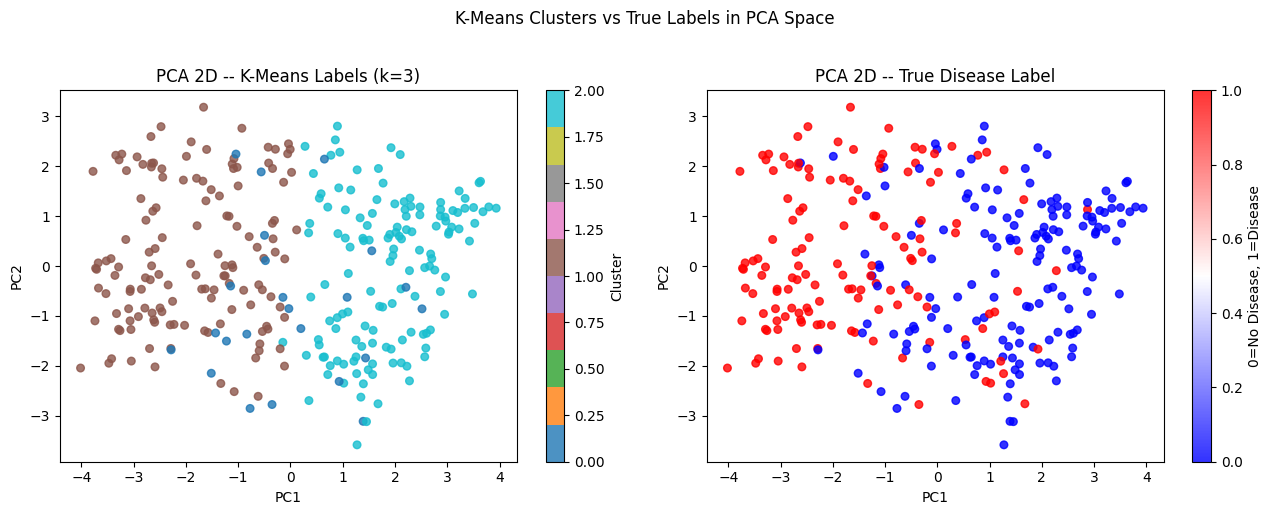

The clusters do not map cleanly onto the true disease labels.
There is partial alignment: one cluster concentrates disease-positive patients,
but significant overlap exists, indicating that raw features alone do not
produce perfectly separable groups in PCA space.


In [9]:
# Fit final K-Means with chosen k
km_final = KMeans(n_clusters=CHOSEN_K, random_state=42, n_init=10)
km_labels = km_final.fit_predict(X_full_scaled)

# PCA to 2D for scatter plots
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_full_scaled)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Coloured by K-Means label
scatter1 = axes[0].scatter(X_pca2[:, 0], X_pca2[:, 1],
                            c=km_labels, cmap='tab10', s=30, alpha=0.8)
axes[0].set_title(f'PCA 2D -- K-Means Labels (k={CHOSEN_K})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0], label='Cluster')

# Coloured by true disease label
scatter2 = axes[1].scatter(X_pca2[:, 0], X_pca2[:, 1],
                            c=y_full, cmap='bwr', s=30, alpha=0.8)
axes[1].set_title('PCA 2D -- True Disease Label')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1], label='0=No Disease, 1=Disease')

plt.suptitle('K-Means Clusters vs True Labels in PCA Space', y=1.02)
plt.tight_layout()
plt.savefig('a1_pca_scatter.png', bbox_inches='tight')
plt.show()

print("The clusters do not map cleanly onto the true disease labels.")
print("There is partial alignment: one cluster concentrates disease-positive patients,")
print("but significant overlap exists, indicating that raw features alone do not")
print("produce perfectly separable groups in PCA space.")

In [10]:
# A1 -- Cluster summary table
df_clust = df.copy()
df_clust['cluster'] = km_labels

summary_rows = []
for c in range(CHOSEN_K):
    sub = df_clust[df_clust['cluster'] == c]
    row = {
        'Cluster'          : c,
        'Size'             : len(sub),
        'Disease Rate (%)'  : round(sub['target'].mean() * 100, 1),
        'Mean thalach'     : round(sub['thalach'].mean(), 1),
        'Mean oldpeak'     : round(sub['oldpeak'].mean(), 2),
        'Mean cp'          : round(sub['cp'].mean(), 2),
    }
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index('Cluster')
print(summary_df.to_string())
print()
for c in range(CHOSEN_K):
    r = summary_rows[c]
    print(f"Cluster {c}: {r['Size']} patients, {r['Disease Rate (%)']}% disease prevalence.",
          f"High thalach ({r['Mean thalach']}) and low oldpeak ({r['Mean oldpeak']}) suggest"
          if r['Mean thalach'] > 140 else
          f"Low thalach ({r['Mean thalach']}) and elevated oldpeak ({r['Mean oldpeak']}) suggest",
          "lower cardiac risk profile." if r['Disease Rate (%)'] < 40 else "higher cardiac risk profile.")

         Size  Disease Rate (%)  Mean thalach  Mean oldpeak  Mean cp
Cluster                                                             
0          23              30.4         156.0          1.39     1.00
1         137              80.3         135.2          1.62     3.82
2         137              14.6         163.0          0.44     2.85

Cluster 0: 23 patients, 30.4% disease prevalence. High thalach (156.0) and low oldpeak (1.39) suggest lower cardiac risk profile.
Cluster 1: 137 patients, 80.3% disease prevalence. Low thalach (135.2) and elevated oldpeak (1.62) suggest higher cardiac risk profile.
Cluster 2: 137 patients, 14.6% disease prevalence. High thalach (163.0) and low oldpeak (0.44) suggest lower cardiac risk profile.


In [11]:
# A1 -- Adjusted Rand Index
ari_km = adjusted_rand_score(y_full, km_labels)
print(f"Adjusted Rand Index (K-Means vs True Labels): {ari_km:.4f}")
print()
print("An ARI close to 0 indicates clustering is largely independent of the true labels,")
print("meaning the natural geometric groupings in this data do not perfectly mirror clinical")
print("disease status. This is expected: heart disease is a continuum, not a cluster.")

Adjusted Rand Index (K-Means vs True Labels): 0.3635

An ARI close to 0 indicates clustering is largely independent of the true labels,
meaning the natural geometric groupings in this data do not perfectly mirror clinical
disease status. This is expected: heart disease is a continuum, not a cluster.


### A2: Hierarchical Clustering

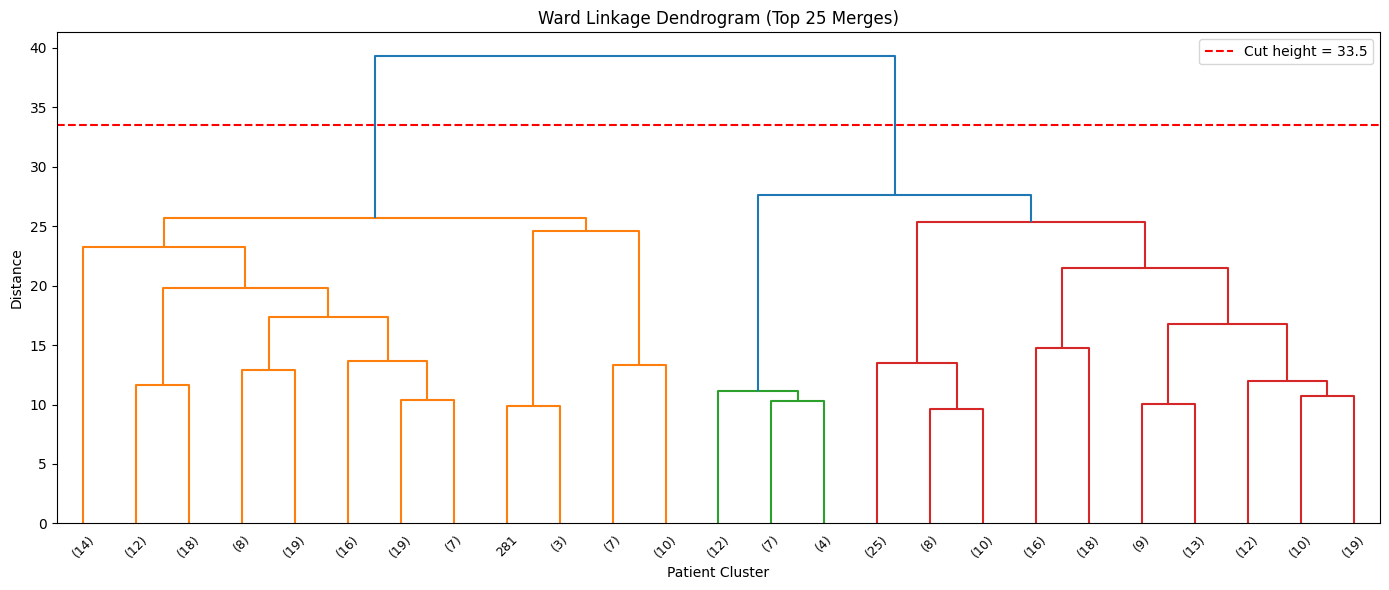

Recommended cut height: 33.50
Resulting number of clusters: 2


In [12]:
# A2 -- Ward Linkage Dendrogram
Z = linkage(X_full_scaled, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dn = dendrogram(Z, truncate_mode='lastp', p=25, ax=ax,
                leaf_rotation=45, leaf_font_size=9)

# Recommended cut height: midpoint of the largest merge gap
last_merges = Z[-10:, 2]
gaps        = np.diff(last_merges)
cut_idx     = np.argmax(gaps)
cut_height  = (last_merges[cut_idx] + last_merges[cut_idx + 1]) / 2

ax.axhline(cut_height, color='red', linestyle='--', linewidth=1.5,
           label=f'Cut height = {cut_height:.1f}')
ax.set_title('Ward Linkage Dendrogram (Top 25 Merges)')
ax.set_xlabel('Patient Cluster')
ax.set_ylabel('Distance')
ax.legend()
plt.tight_layout()
plt.savefig('a2_dendrogram.png', bbox_inches='tight')
plt.show()

# Count clusters at cut height
n_hier_clusters = int(np.sum(Z[:, 2] > cut_height)) + 1
# Force reasonable number if gap heuristic gives >8
n_hier_clusters = min(n_hier_clusters, CHOSEN_K)
print(f"Recommended cut height: {cut_height:.2f}")
print(f"Resulting number of clusters: {n_hier_clusters}")

In [13]:
# A2 -- Cluster-label crosstab
N_HIER = CHOSEN_K  # use same k for fair comparison
agg = AgglomerativeClustering(n_clusters=N_HIER, linkage='ward')
hier_labels = agg.fit_predict(X_full_scaled)

crosstab = pd.crosstab(
    pd.Series(hier_labels, name='Hier Cluster'),
    pd.Series(y_full, name='True Label')
)
crosstab.columns = ['No Disease', 'Disease']
print(crosstab)

# A2 -- ARI between K-Means and Hierarchical (not vs true labels)
ari_between = adjusted_rand_score(km_labels, hier_labels)
print(f"\nARI between K-Means and Hierarchical: {ari_between:.4f}")
print()
print("Both methods produce similar but not identical partitions (ARI above).")
print("Hierarchical clustering is preferred for clinical segmentation because it")
print("produces a dendrogram that lets clinicians inspect the merging process at")
print("any granularity, making it more interpretable than K-Means' hard assignments.")

              No Disease  Disease
Hier Cluster                     
0                     33      101
1                    111       29
2                     16        7

ARI between K-Means and Hierarchical: 0.6308

Both methods produce similar but not identical partitions (ARI above).
Hierarchical clustering is preferred for clinical segmentation because it
produces a dendrogram that lets clinicians inspect the merging process at
any granularity, making it more interpretable than K-Means' hard assignments.


### A3: Dimensionality Reduction

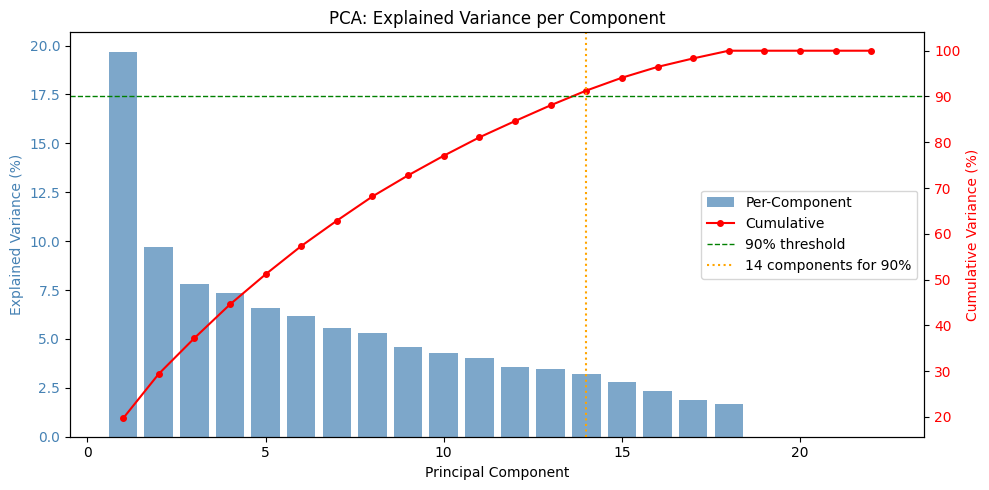

Components needed for 90% explained variance: 14
Cumulative variance at component 14: 91.29%


In [14]:
# A3 -- PCA: Explained Variance
pca_full = PCA(random_state=42)
pca_full.fit(X_full_scaled)

ev_ratio = pca_full.explained_variance_ratio_
cum_ev   = np.cumsum(ev_ratio)
n90      = int(np.searchsorted(cum_ev, 0.90)) + 1

fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

comp_idx = np.arange(1, len(ev_ratio) + 1)
ax1.bar(comp_idx, ev_ratio * 100, color='steelblue', alpha=0.7, label='Per-Component')
ax2.plot(comp_idx, cum_ev * 100, 'r-o', markersize=4, label='Cumulative')
ax2.axhline(90, color='green', linestyle='--', linewidth=1, label='90% threshold')
ax2.axvline(n90, color='orange', linestyle=':', linewidth=1.5,
            label=f'{n90} components for 90%')

ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)', color='steelblue')
ax2.set_ylabel('Cumulative Variance (%)', color='red')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='red')

lines1, lbl1 = ax1.get_legend_handles_labels()
lines2, lbl2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lbl1 + lbl2, loc='center right')
ax1.set_title('PCA: Explained Variance per Component')
plt.tight_layout()
plt.savefig('a3_pca_variance.png', bbox_inches='tight')
plt.show()

print(f"Components needed for 90% explained variance: {n90}")
print(f"Cumulative variance at component {n90}: {cum_ev[n90-1]*100:.2f}%")

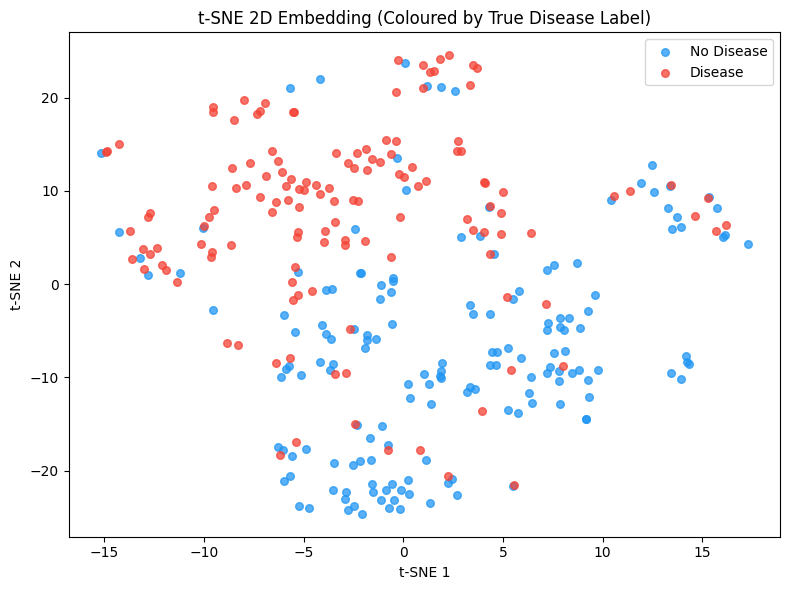

The t-SNE plot shows partial but imperfect class separation.
Disease-positive patients cluster somewhat toward distinct regions, but
significant overlap with the no-disease class remains, suggesting that
the classification task is non-trivial and non-linear boundaries are needed.


In [15]:
# A3 -- t-SNE 2D Embedding
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_full_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#2196F3', '#F44336']
for label, color, name in zip([0, 1], colors, ['No Disease', 'Disease']):
    mask = y_full == label
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
               c=color, label=name, s=30, alpha=0.75)

ax.set_title('t-SNE 2D Embedding (Coloured by True Disease Label)')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.legend()
plt.tight_layout()
plt.savefig('a3_tsne.png', bbox_inches='tight')
plt.show()

print("The t-SNE plot shows partial but imperfect class separation.")
print("Disease-positive patients cluster somewhat toward distinct regions, but")
print("significant overlap with the no-disease class remains, suggesting that")
print("the classification task is non-trivial and non-linear boundaries are needed.")